# TCC: 03 - Análise Exploratória e Fusão de Bases (Merge Longitudinal)

Neste notebook, iniciamos a exploração visual das duas grandes bases já padronizadas (SIH e CNES) e realizamos o cruzamento rigoroso utilizando **Data (Mês/Ano) + Hospital** para evitar data-leakage e garantir a foto histórica exata da infraestrutura hospitalar.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

# Adiciona a raiz do projeto
ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'

sns.set_theme(style="whitegrid", palette="muted")

## 1. Carregamento das Bases de Modelagem

In [6]:
# Carrega apenas as bases prontas para modelagem (sem _cod)
df_sih = pd.read_csv(INTERIM / "sih_iam_modelagem.csv", low_memory=False)
df_cnes = pd.read_csv(INTERIM / "cnes_hospitais_modelagem.csv", low_memory=False)

print(f"SIH-IAM: {df_sih.shape[0]:,} internações")
print(f"CNES:    {df_cnes.shape[0]:,} fotos hospitalares (meses)")

SIH-IAM: 168,816 internações
CNES:    66,140 fotos hospitalares (meses)


## 2. Análise Exploratória Rápida (EDA)

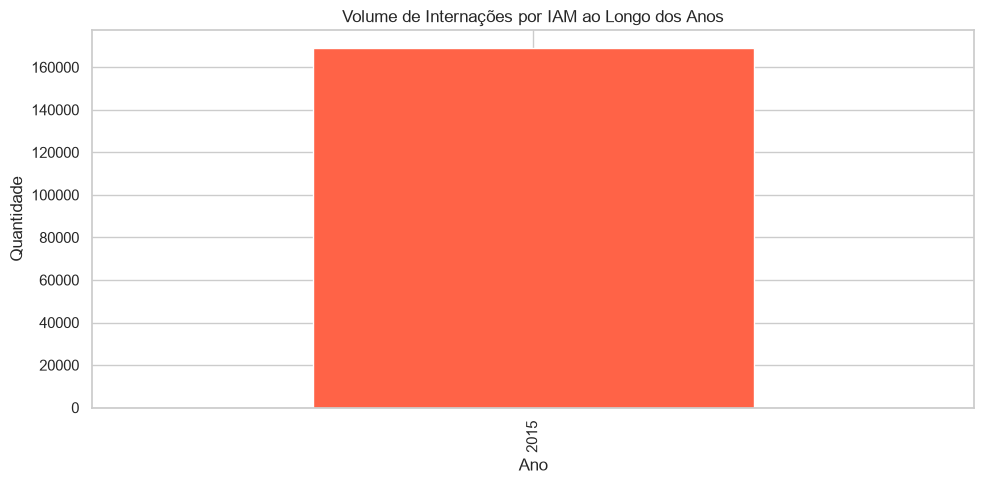

In [7]:
# Evolução temporal do IAM
df_sih['ano_competencia'] = df_sih['ano_competencia'].astype(str).str.replace('.0', '', regex=False)
df_sih['mes_competencia'] = df_sih['mes_competencia'].astype(str).str.replace('.0', '', regex=False).str.zfill(2)

plt.figure(figsize=(10, 5))
df_sih.groupby('ano_competencia').size().plot(kind='bar', color='tomato')
plt.title("Volume de Internações por IAM ao Longo dos Anos")
plt.ylabel("Quantidade")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

## 3. Preparação das Chaves Longitudinais

In [8]:
# 1. Cria a chave de competência (YYYYMM) no SIH para coincidir com o CNES
df_sih['competencia'] = df_sih['ano_competencia'] + df_sih['mes_competencia']

# 2. Garante que os tipos das chaves sejam idênticos em ambas as bases
df_sih['codigo_cnes'] = df_sih['codigo_cnes'].astype(str).str.strip().str.zfill(7)
df_sih['competencia'] = df_sih['competencia'].astype(str).str.strip()

df_cnes['codigo_cnes'] = df_cnes['codigo_cnes'].astype(str).str.strip().str.zfill(7)
df_cnes['competencia'] = df_cnes['competencia'].astype(str).str.strip()

print("Amostra de chaves (SIH):")
print(df_sih[['codigo_cnes', 'competencia']].head())
print("\nAmostra de chaves (CNES):")
print(df_cnes[['codigo_cnes', 'competencia']].head())

Amostra de chaves (SIH):
  codigo_cnes competencia
0     2091275      201501
1     2091275      201501
2     2091275      201501
3     2091275      201501
4     2091275      201501

Amostra de chaves (CNES):
  codigo_cnes competencia
0     2025825      201501
1     2025833      201501
2     2035766      201501
3     2056100      201501
4     2077647      201501


## 4. O Grande Merge Longitudinal

Fazemos o `Left Join` usando Hospital + Mês. Assim, a infraestrutura hospitalar refletida no modelo de IA será a que existia **naquele exato mês da internação**.

In [10]:
# Left Join no nível Hospital-Mês
df_base_modelagem = pd.merge(
    df_sih,
    df_cnes,
    on=['codigo_cnes', 'competencia'],
    how='left',
    suffixes=('', '_cnes')
)

print(f"Linhas ANTES do merge:  {len(df_sih):,}")
print(f"Linhas DEPOIS do merge: {len(df_base_modelagem):,}")

# Validação de Match
# Verificamos quantos hospitais foram encontrados na base CNES naquele mês exato
taxa_match = df_base_modelagem['cep_estabelecimento'].notnull().mean() * 100
print(f"\nTaxa de sucesso do cruzamento (Match rate): {taxa_match:.2f}%")

if taxa_match < 50:
    print("\n⚠️ ALERTA: Match rate muito baixo! Isso geralmente ocorre quando a base do CNES baixada não contempla os mesmos anos/meses da base SIH.")


Linhas ANTES do merge:  168,816
Linhas DEPOIS do merge: 168,816

Taxa de sucesso do cruzamento (Match rate): 100.00%


## 5. Exportação da Base Final

In [ ]:
path_base_final = PROCESSED / "base_modelagem.csv"
df_base_modelagem.to_csv(path_base_final, index=False)
print(f"✅ Base final exportada para {path_base_final}")